In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("/Users/riritorti/Documents/GitHub/AI-Immigration/Data/raw/crude_oil_export_voy_intake_index.csv")

In [17]:
print(df.head())

         date  voy_intake_index  ma_7day  prior_year_ma_7day
0  2025-01-01        121.443682   121.44                 NaN
1  2025-01-02         64.317862    92.88                 NaN
2  2025-01-03        109.979211    98.58                 NaN
3  2025-01-04        102.510892    99.56                 NaN
4  2025-01-05        127.754218   105.20                 NaN


In [18]:
print(df.columns)

Index(['date', 'voy_intake_index', 'ma_7day', 'prior_year_ma_7day'], dtype='object')


In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                526 non-null    object 
 1   voy_intake_index    526 non-null    float64
 2   ma_7day             526 non-null    float64
 3   prior_year_ma_7day  161 non-null    float64
dtypes: float64(3), object(1)
memory usage: 16.6+ KB
None


In [22]:
df['date'] = pd.to_datetime(df['date'])
print(df.dtypes)

date                  datetime64[ns]
voy_intake_index             float64
ma_7day                      float64
prior_year_ma_7day           float64
dtype: object


In [21]:
df_2026 = df[df['date'].dt.year == 2026].copy()
print(df_2026.head())

          date  voy_intake_index  ma_7day  prior_year_ma_7day
365 2026-01-01         50.851046   101.06              121.44
366 2026-01-02        154.550866   108.30               92.88
367 2026-01-03         95.268373   111.63               98.58
368 2026-01-04         81.793019   111.05               99.56
369 2026-01-05         98.996626    99.67              105.20


In [23]:
df_2026 = df[df['date'].dt.year == 2026].copy()
print(df_2026.tail())

          date  voy_intake_index  ma_7day  prior_year_ma_7day
521 2026-06-06               0.0      0.0              103.38
522 2026-06-07               0.0      0.0              104.93
523 2026-06-08               0.0      0.0              109.11
524 2026-06-09               0.0      0.0              105.24
525 2026-06-10               0.0      0.0              104.15


In [24]:
df_2026['ma_7day'] = (
    df_2026['voy_intake_index']
    .rolling(window=7)
    .mean()
)

In [25]:
print(df_2026[['date', 'voy_intake_index', 'ma_7day']].head(15))

          date  voy_intake_index     ma_7day
365 2026-01-01         50.851046         NaN
366 2026-01-02        154.550866         NaN
367 2026-01-03         95.268373         NaN
368 2026-01-04         81.793019         NaN
369 2026-01-05         98.996626         NaN
370 2026-01-06         82.265025         NaN
371 2026-01-07        106.565038   95.755713
372 2026-01-08         97.911711  102.478665
373 2026-01-09        118.590760   97.341507
374 2026-01-10        131.778024  102.557172
375 2026-01-11         98.497986  104.943596
376 2026-01-12        109.917673  106.503745
377 2026-01-13         98.767067  108.861180
378 2026-01-14         96.443178  107.415200
379 2026-01-15         74.300536  104.042175


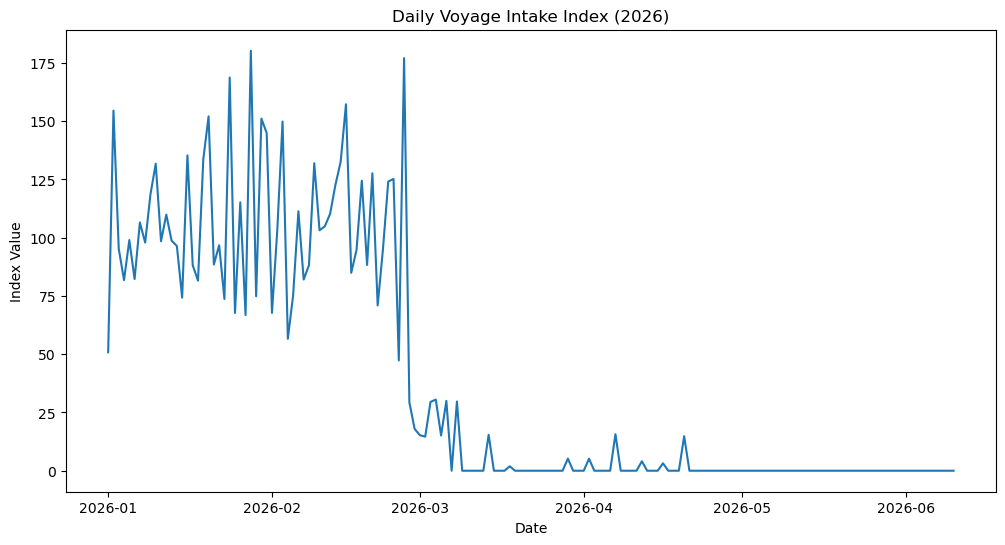

In [26]:
plt.figure(figsize=(12,6))

plt.plot(
    df_2026['date'],
    df_2026['voy_intake_index']
)

plt.title("Daily Voyage Intake Index (2026)")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.show()

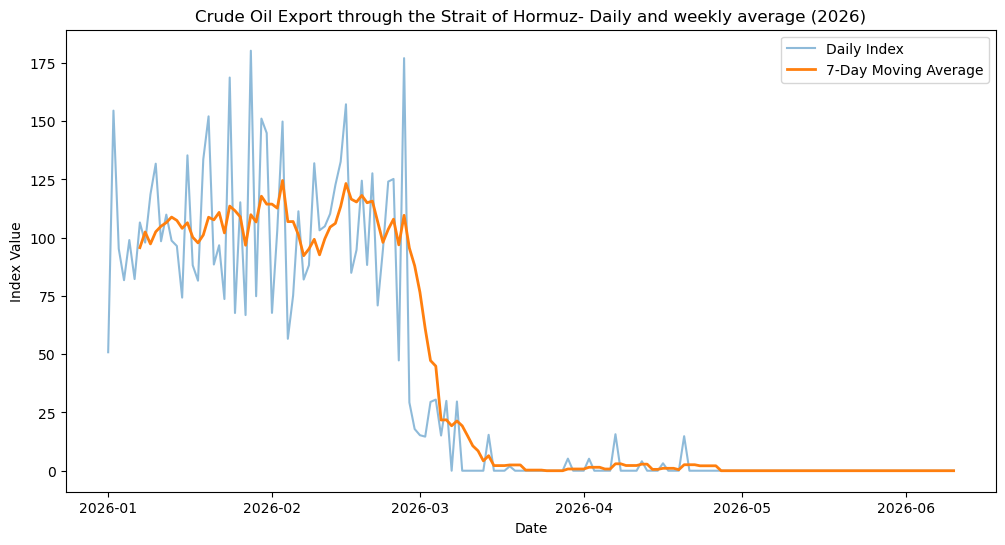

In [30]:
plt.figure(figsize=(12,6))

plt.plot(
    df_2026['date'],
    df_2026['voy_intake_index'],
    alpha=0.5,
    label='Daily Index'
)

plt.plot(
    df_2026['date'],
    df_2026['ma_7day'],
    linewidth=2,
    label='7-Day Moving Average'
)

plt.legend()

plt.title("Crude Oil Export through the Strait of Hormuz- Daily and weekly average (2026)")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.show()
